<a href="https://colab.research.google.com/github/DAGP1145/Machinlearning/blob/Ramita-para-subir-cosas/Machinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis exploratorio de datos (EDA)

QUÈ ES?

#EDA And SUPERSTORE
##Problem Definition

The main objective of this analysis is to understand how sales and profit evolve over time.

Specifically, this study aims to answer the following question:

> How do sales and profit change over time, and what factors influence their variation?

To address this, the Global Superstore dataset will be analyzed using Exploratory Data Analysis (EDA), focusing on identifying trends, seasonal patterns, and anomalies in both sales and profit.

---

##Analysis questions


1.   How do sales evolve over time across different product categories?

2. Which cities, countries, markets, and market2 segments show the highest sales performance?

3. Which customer segment has the greatest presence in the market?

4. Which products are the most sold? Do these same products generate profit? If not, what is the loss margin?

5. Do discounts affect profitability? If so, how?

6. Is there a relationship between order priority and the time interval between order date and ship date? Is this related to ship mode and shipping cost? What impact does this have on company profit or loss?



## Data Dictionary

### 1.- Temporal Variables

| Variable | Description | Value |
|----------|------------|-------|
| Order.Date | order_date: The date when the order was placed. |  |
| Ship.Date | ship_date: The date when the order was shipped. |  |

### 2.- Nominal Categorical Variables

| Variable | Description | Value |
|----------|------------|-------|
| Customer.ID | customer_id: A unique identifier for each customer. |  |
| Order.ID | order_id: A unique identifier for each order. |  |
| Product.ID | product_id: A unique identifier for each product. |  |
| Row.ID | row_id: A unique identifier for each row in the dataset. |  |
| Customer.Name | customer_name: The name of the customer who placed the order. |  |
| Category | The category of products sold in the superstore. |  |
| Sub.Category | sub_category: The subcategory of products within the main category. |  |
| Product.Name | product_name: The name of the product. |  |
| City | The city where the order was placed. |  |
| State | state: The state or region within the country. |  |
| Country | The country in which the superstore is located. |  |
| Region | region: The region where the order was placed. |  |
| Market | market: The market or region where the superstore operates. | APAC, LATAM, EU, US, EMEA, Africa, Canada |
| Market2 | market2: Another column related to market information. | APAC, North America, LATAM, EU, EMEA, Africa |
|Segment | The customer segment | Consumer, Corporate, Home Office

### 3.- Ordinal Categorical Variables

| Variable | Description | Value |
|----------|------------|-------|
| Order.Priority | order_priority: The priority level of the order. | Critical, High, Medium, Low |
| Ship.Mode | The shipping mode used for the order. | First Class, Second Class, Standard Class, Same Day |

### 4.- Discrete Numerical Variables

| Variable | Description | Value |
|----------|------------|-------|
| Quantity | quantity: The quantity of products ordered. |  |
| Year | year: The year in which the order was placed. |  |
| Weeknum | weeknum: The week number when the order was placed. |  |

### 5.-Continuous Numerical Variables

| Variable | Description | Value |
|----------|------------|-------|
| Sales | sales: The total sales amount for the order. |  |
| Discount | discount: The discount applied to the order. |  |
| Profit | profit: The profit generated from the order. |  |
| Shipping.Cost | shipping_cost: The cost of shipping for the order. |  |



## Transaction Structure

The dataset can be interpreted as a **global transaction record**, where each row represents a complete commercial transaction.  
This transaction integrates multiple dimensions that describe different aspects of the business process.

Instead of analyzing variables in isolation, it is more appropriate to group them into logical entities such as customer, product, geography, and order details.

---

### 1. Customer Dimension

Variables that describe the customer involved in the transaction:

- customer_id  
- customer_name  
- segment  

These variables allow identification and segmentation of customers.

---

### 2. Product Dimension

Variables that describe the product being sold:

- product_id  
- product_name  
- category  
- sub_category  

These attributes define the type and classification of products.

---

### 3. Geographic Dimension

Variables that describe where the transaction takes place:

- city  
- state  
- country  
- region  
- market  
- market2  

These variables enable geographic and market-based analysis.

---

### 4. Order / Transaction Dimension

Variables that define the transaction itself:

- order_id  
- order_date  
- order_priority  
- ship_date  
- ship_mode  
- row_id  

These attributes describe the lifecycle and logistics of the order.

---

### 5. Sales / Performance Metrics

Quantitative variables that measure the outcome of the transaction:

- sales  
- profit  
- discount  
- quantity  
- shipping_cost  

These variables are key for business performance analysis.

---

### 6. Temporal Dimension

Variables derived from time for analytical purposes:

- year  
- weeknum  

These support time series and trend analysis.

---

### 7. Other Variables

- ji_lu_shu  

This variable is currently undefined and requires further inspection.



# 1- Librerias
Antes de empezar vamos a importar las siguientes librerías:

Pandas
Numpy
Matplotlib

In [46]:
import numpy as np # Programación vectorial
import matplotlib.pyplot as plt # Visualización
import pandas as pd # Estructura y manipulación de datos

# 2- Cargar archivo

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fatihilhan/global-superstore-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-superstore-dataset' dataset.
Path to dataset files: /kaggle/input/global-superstore-dataset


In [60]:
!ls /root/.cache/kagglehub/datasets/fatihilhan/global-superstore-dataset/versions/1

superstore.csv


In [61]:
df = pd.read_csv(f"{path}/superstore.csv")

#3- Exploración Inicial de los datos

In [92]:
# Visualizar las primeras 5 filas
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [22]:
# Visualizar las ultimas 5 filas
df.tail()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,...,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,2014-12-18 00:00:00.000,CA-2014-106964,...,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,2014-12-25 00:00:00.000,CA-2014-145219,...,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52
51289,Office Supplies,Los Angeles,United States,FH-143654,Fred Hopkins,0.2,US,1,2014-12-26 00:00:00.000,CA-2014-121398,...,154,Corporate,2014-12-30 00:00:00.000,Standard Class,9.59,California,Binders,2014,North America,52


# Exploración inicial de los datos

In [ ]:
df.shape

(51290, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [ ]:
df.dtypes

,0
Category,object
City,object
Country,object
Customer.ID,object
Customer.Name,object
Discount,float64
Market,object
记录数,int64
Order.Date,object
Order.ID,object


In [ ]:
# Obtener las estadísticas descriptivas de las variables numéricas
# Variables numéricas
print("Variables numéricas\n")
df.describe().T.round(2)

Variables numéricas



,count,mean,std,min,25%,50%,75%,max
Discount,51290.0,0.14,0.21,0.00,0.00,0.00,0.20,0.85
记录数,51290.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Profit,51290.0,28.61,174.34,-6599.98,0.00,9.24,36.81,8399.98
Quantity,51290.0,3.48,2.28,1.00,2.00,3.00,5.00,14.00
Row.ID,51290.0,25645.50,14806.29,1.00,12823.25,25645.50,38467.75,51290.00
Sales,51290.0,246.50,487.57,0.00,31.00,85.00,251.00,22638.00
Shipping.Cost,51290.0,26.38,57.30,0.00,2.61,7.79,24.45,933.57
Year,51290.0,2012.78,1.10,2011.00,2012.00,2013.00,2014.00,2014.00
weeknum,51290.0,31.29,14.43,1.00,20.00,33.00,44.00,53.00


## Descuentos
1. Promedio de descuentos es de: 0.14.
2. Desviación estandar es de: 0.21.
3. Valor minimo de un descuento aplicado es de: 0.
4. Valor maximo de un descuento es de: 85.
##Profit
1. Promedio de Profit es de: 28.61.
2. Desviación estandar es de: 174.34.
3. Valor minimo de un Profit aplicado es de: -6599.98.
4. Valor maximo de un Profit es de: 8399.98.
##Quantity
1. Promedio de Quantity es de: 3.48.
2. Desviación estandar es de: 2.28.
3. Valor minimo de un Quantity aplicado es de: 1.00.
4. Valor maximo de un Quantity es de: 14.00.
##Sales
1. Promedio de Sales 246.50.
2. Desviación estandar es de	487.57.
3. Valor minimo de Sales	0.00.
4. Valor máximo	22638.00.
##Shipping.Cost
1. Promedio de Shopping.Cost 26.38.
2. Desviación estandar es de 57.30.
3. Valor minimo de Shopping.Cost 0.00.
4. Valor máximo de Shooping.Cost 933.57.





In [ ]:
df.columns.to_list()

['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Discount',
 'Market',
 '记录数',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Profit',
 'Quantity',
 'Region',
 'Row.ID',
 'Sales',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'Shipping.Cost',
 'State',
 'Sub.Category',
 'Year',
 'Market2',
 'weeknum']

In [45]:
df_objetos = df.select_dtypes(include=['object'])

# Variables categóricas
print("Variables categóricas")
for col in df_objetos:
  print(f"\n{col}: \n{df[col].value_counts()}")

#Seleccionamos las columnas categoricas del DataFrame y luego mostramos el recuento de cada valor único dentro de esas columnas.
# Esto nos da una visión clara de la diversidad y la frecuencia de los datos cualitativos.
#'Length' nos indica cuántos valores únicos diferentes hay en esa columna categórica.
# Por ejemplo, si tenemos una columna 'City' y el resultado muestra Length: 3636, significa que hay 3636 ciudades diferentes registradas en tus datos.

Variables categóricas

Category: 
Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

City: 
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Santo Domingo    443
                ... 
Chapel Hill        1
Goldsboro          1
Bartlett           1
Ormond Beach       1
Cuneo              1
Name: count, Length: 3636, dtype: int64

Country: 
Country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
Bahrain             2
Swaziland           2
Eritrea             2
South Sudan         2
Burundi             2
Name: count, Length: 147, dtype: int64

Customer.ID: 
Customer.ID
JG-158051    40
BC-111252    37
WB-218504    37
AF-108701    36
NH-186101    35
             ..
LD-168554     1
CS-21303      1
DP-31652      1
AC-6602       1
EH-39902      1
Name: count, Length: 4873, dtype: int64

Customer.Name: 
Customer.Nam

In [40]:
df.dtypes

,0
Category,object
City,object
Country,object
Customer.ID,object
Customer.Name,object
Discount,float64
Market,object
记录数,int64
Order.Date,datetime64[ns]
Order.ID,object


## Valores nulos

In [ ]:
df.isnull().any().any()
# Dio como resultado np.False_. No hay valores nulos en ninguna parte del DataFrame.

np.False_

In [32]:
#Podemos comprobar ese resultado de esta forma
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de Category = 0
Total de valores nulos de City = 0
Total de valores nulos de Country = 0
Total de valores nulos de Customer.ID = 0
Total de valores nulos de Customer.Name = 0
Total de valores nulos de Discount = 0
Total de valores nulos de Market = 0
Total de valores nulos de 记录数 = 0
Total de valores nulos de Order.Date = 0
Total de valores nulos de Order.ID = 0
Total de valores nulos de Order.Priority = 0
Total de valores nulos de Product.ID = 0
Total de valores nulos de Product.Name = 0
Total de valores nulos de Profit = 0
Total de valores nulos de Quantity = 0
Total de valores nulos de Region = 0
Total de valores nulos de Row.ID = 0
Total de valores nulos de Sales = 0
Total de valores nulos de Segment = 0
Total de valores nulos de Ship.Date = 0
Total de valores nulos de Ship.Mode = 0
Total de valores nulos de Shipping.Cost = 0
Total de valores nulos de State = 0
Total de valores nulos de Sub.Category = 0
Total de valores nulos de Year = 0
Total de valores nulo

## Un analisis mas detallado de las columnas categoricas

In [ ]:
# Obtener total de pedidos considerando tipo de comida y género
data_frame.groupby('Gender')['Food'].value_counts()

# 4- Visualizaciòn de los datos numericos

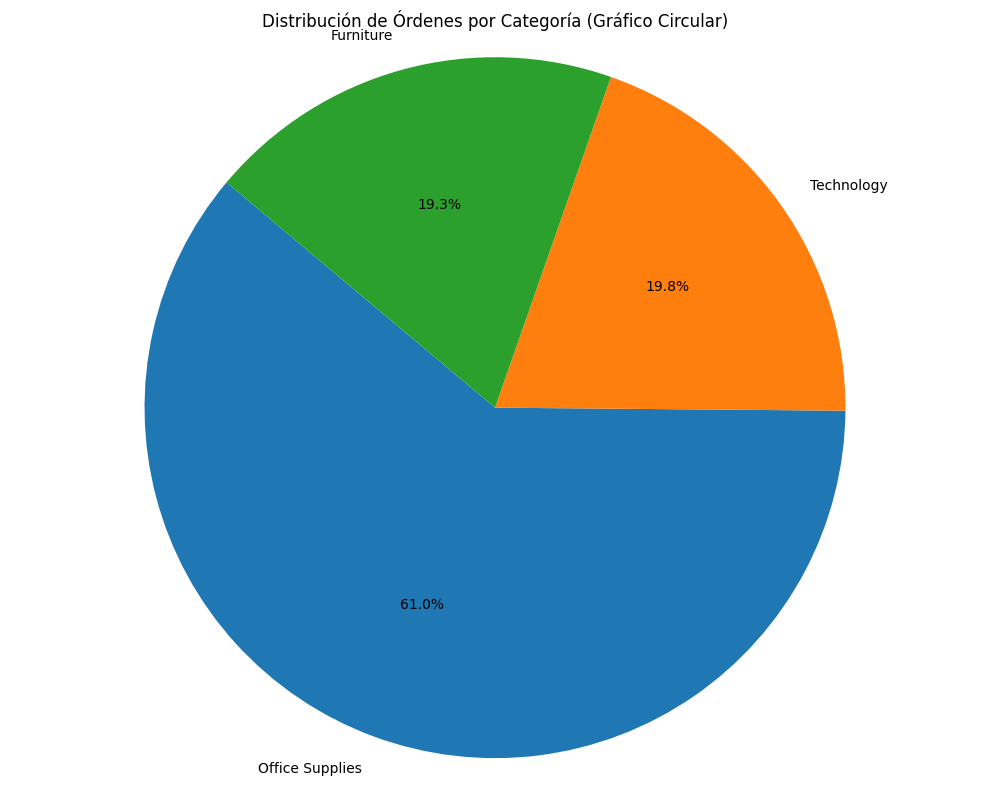

In [177]:
Contable = df['Category'].nunique()
CATEGORY = df['Category'].value_counts().head(Contable)

plt.figure(figsize=(10, 8))
plt.pie(CATEGORY.values, labels=CATEGORY.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Órdenes por Categoría (Gráfico Circular)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

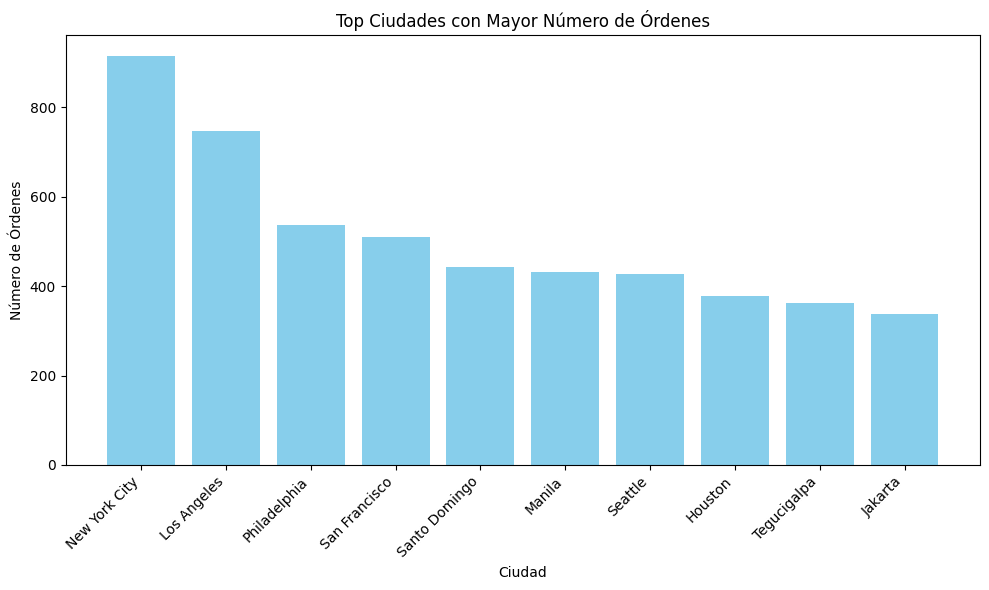

In [158]:
top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_cities.index, top_cities.values, color='skyblue')
plt.title('Top Ciudades con Mayor Número de Órdenes')
plt.xlabel('Ciudad')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

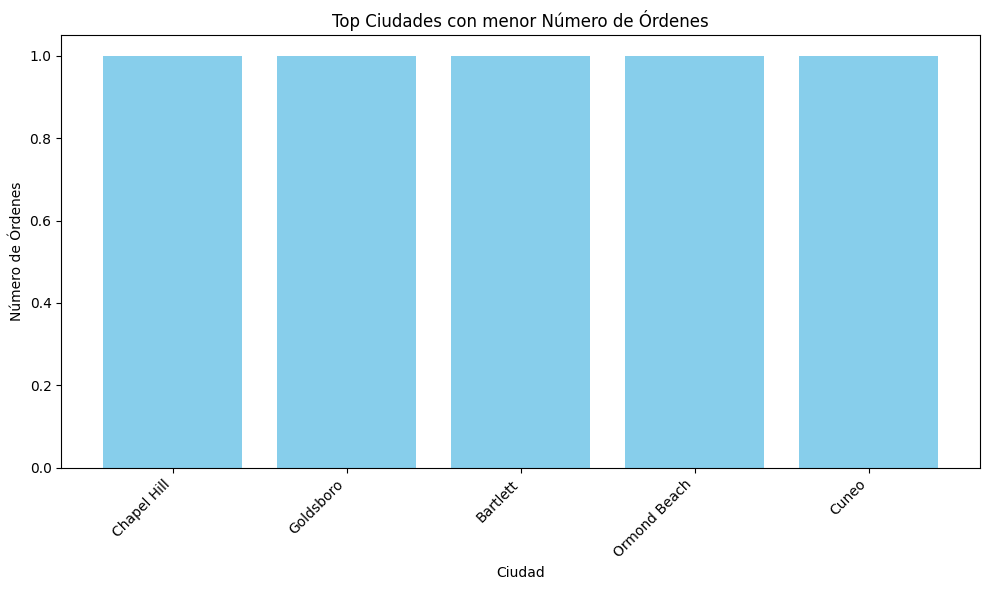

In [159]:
topmin_10_cities = df['City'].value_counts().tail()

plt.figure(figsize=(10, 6))
plt.bar(topmin_10_cities.index, topmin_10_cities.values, color='skyblue')
plt.title('Top Ciudades con menor Número de Órdenes')
plt.xlabel('Ciudad')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

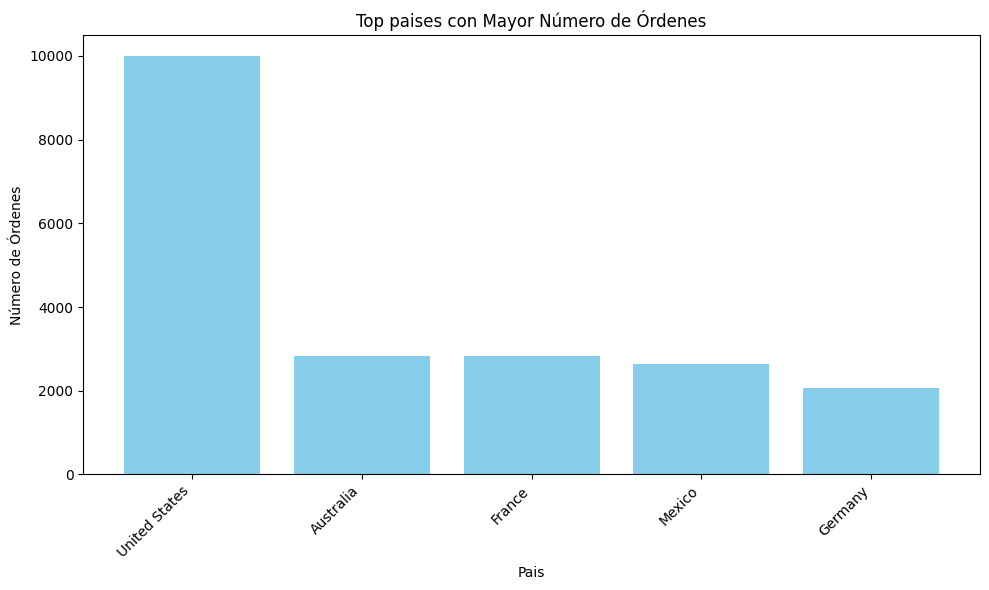

In [160]:
top_Country = df['Country'].value_counts().head()

plt.figure(figsize=(10, 6))
plt.bar(top_Country.index, top_Country.values, color='skyblue')
plt.title('Top paises con Mayor Número de Órdenes')
plt.xlabel('Pais')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

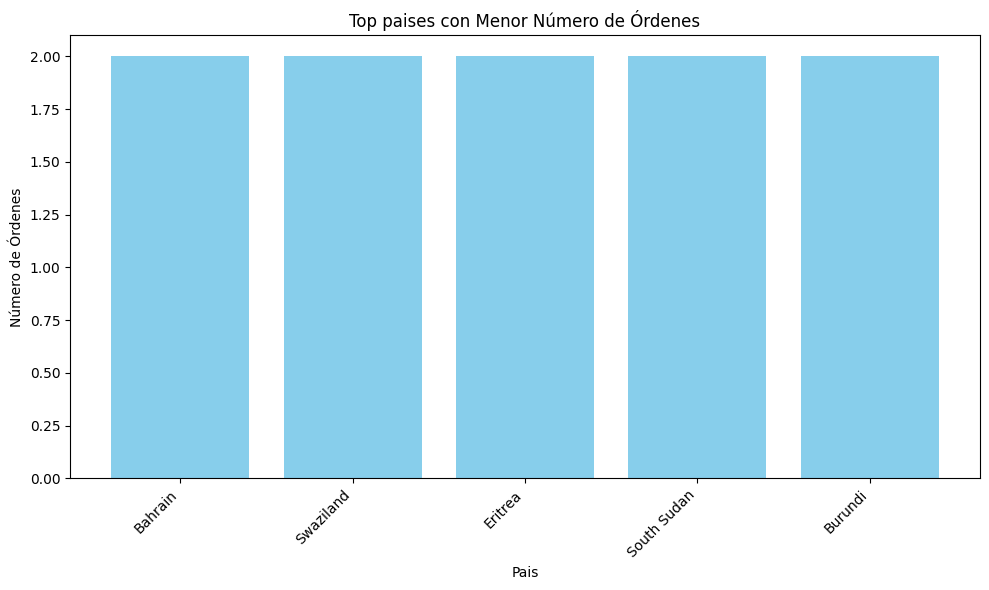

In [161]:
top_Country = df['Country'].value_counts().tail()

plt.figure(figsize=(10, 6))
plt.bar(top_Country.index, top_Country.values, color='skyblue')
plt.title('Top paises con Menor Número de Órdenes')
plt.xlabel('Pais')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

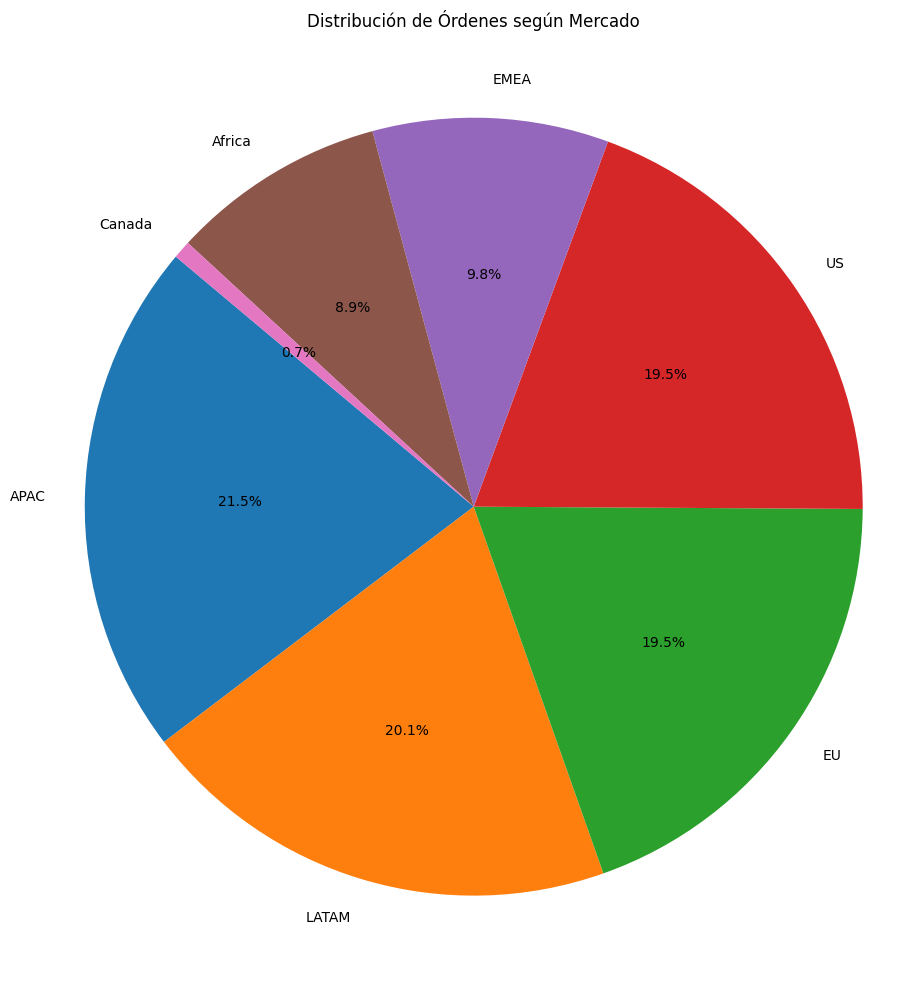

In [175]:
Contable = df['Market'].nunique()
top_Country = df['Market'].value_counts().tail(Contable)

plt.figure(figsize=(9, 10))
plt.pie(top_Country.values, labels=top_Country.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Órdenes según Mercado')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

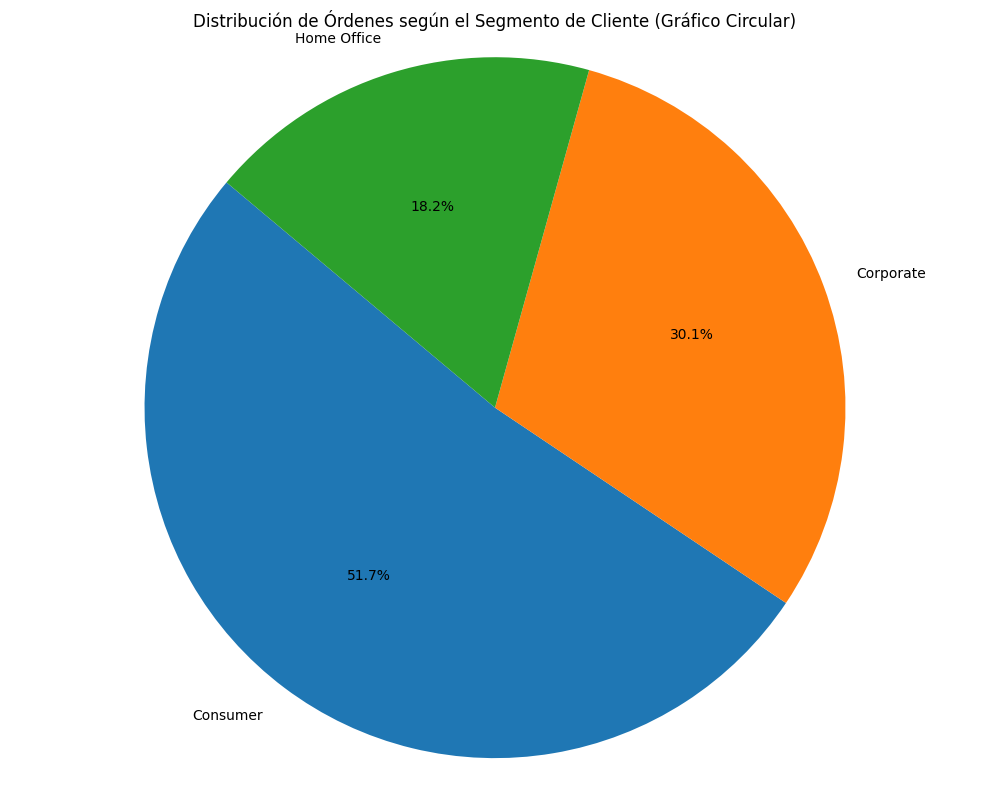

In [182]:
Contable = df['Segment'].nunique()
customer = df['Segment'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(customer.values, labels=customer.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Órdenes según el Segmento de Cliente (Gráfico Circular)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [164]:
df['Product.Name']

,Product.Name
0,Xerox 225
1,"Wirebound Service Call Books, 5 1/2"" x 4"""
2,"Adams Phone Message Book, Professional, 400 Me..."
3,Xerox 1913
4,Xerox 223
...,...
51285,Satellite Sectional Post Binders
51286,Staples
51287,GBC Plastic Binding Combs
51288,Vinyl Sectional Post Binders


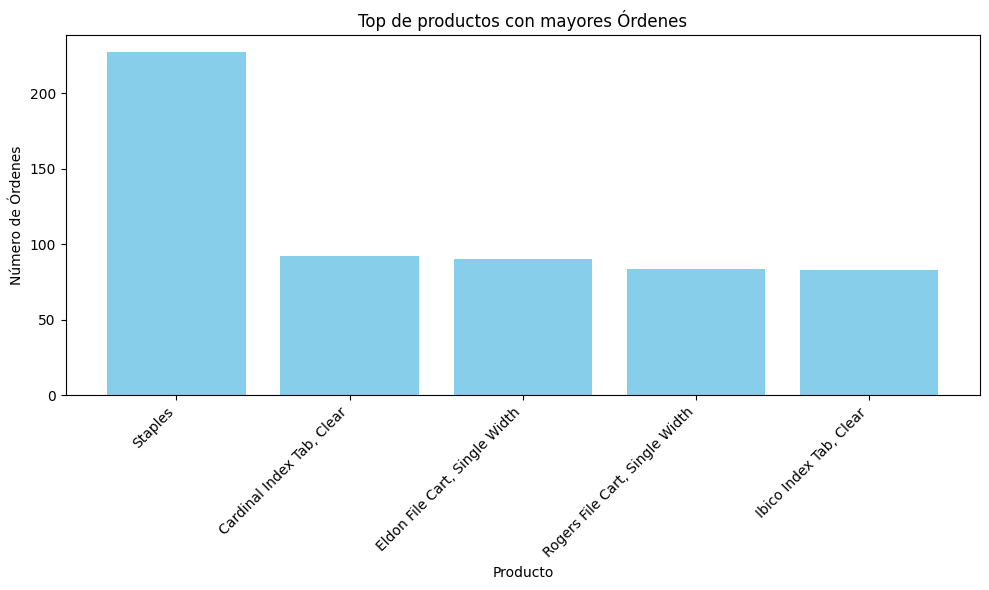

In [167]:
customer = df['Product.Name'].value_counts().head()

plt.figure(figsize=(10, 6))
plt.bar(customer.index, customer.values, color='skyblue')
plt.title('Top de productos con mayores Órdenes')
plt.xlabel('Producto')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

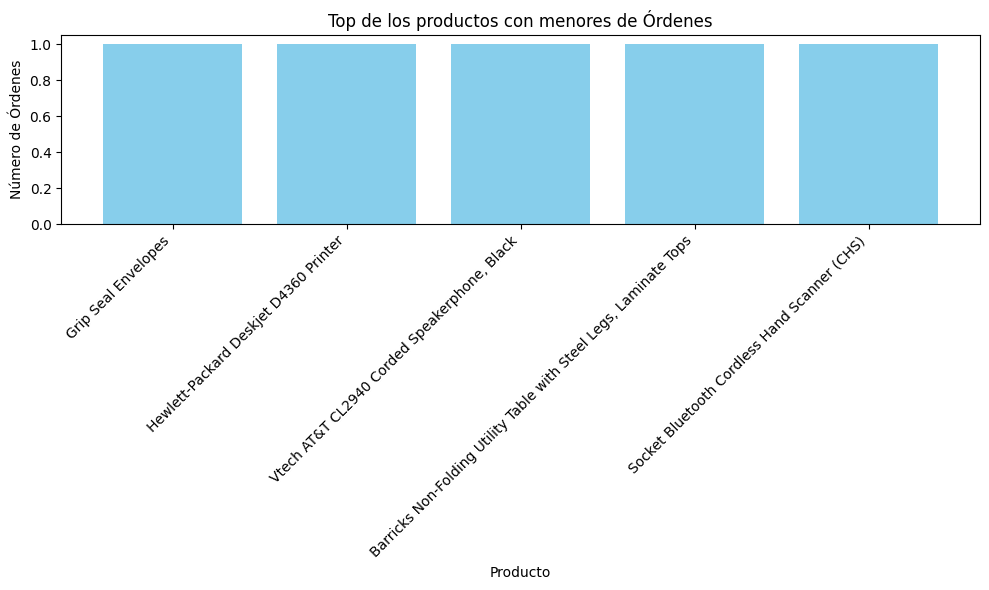

In [168]:
customer = df['Product.Name'].value_counts().tail()

plt.figure(figsize=(10, 6))
plt.bar(customer.index, customer.values, color='skyblue')
plt.title('Top de los productos con menores de Órdenes')
plt.xlabel('Producto')
plt.ylabel('Número de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5- VALIDACIÒN DE LOS DATOS

###VALIDACIÒN DE LOS DATOS CATEGORICOS

# 6- Limpieza

### Eliminando columnas innecesarias

In [ ]:
#Eliminaremos la columna 记录数 ya que no se posee información relevante.
df = df.drop(columns= '记录数' )
display(df.head())

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07 00:00:00.000,CA-2011-130813,High,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21 00:00:00.000,CA-2011-148614,Medium,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05 00:00:00.000,CA-2011-118962,Medium,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29 00:00:00.000,CA-2011-146969,High,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


### Conversiones de columnas

In [50]:
df['Order.Date'] = pd.to_datetime(df[['Order.Date']].stack()).unstack()
df['Ship.Date'] = pd.to_datetime(df[['Ship.Date']].stack()).unstack()
print(df[['Order.Date', 'Ship.Date']].dtypes)

Order.Date    datetime64[ns]
Ship.Date     datetime64[ns]
dtype: object


# 7- Manejo de outliers**

### **IQR (rango intercuartil) en Box plots**

### **Identificación de umbrales**

### **Identificando outliers**

### **Subconjunto de los datos**

### **Eliminando los outliers**

### **Comparación con outliers y sin outliers**

# 8- Explorar las relaciones entre las variables**

### **Correlación**

### **Mapas de calor de correlación**